# ROME causal tracing and rank-one editing

This notebook reruns two experiments from [*Locating and Editing Factual Associations in GPT*](https://arxiv.org/abs/2202.05262) with GPT-2 XL. For three published facts, TDHook causal traces are compared directly with the released ROME implementation. Ten CounterFact edits then use ROME's rank-one update through a temporary TDHook parameter replacement.

This is the reproduction for [issue #109](https://github.com/Xmaster6y/tdhook/issues/109). It needs CUDA, about 7 GB of downloads, and the official ROME checkout at revision `0874014cd9837e4365f3e6f3c71400ef11509e04` on `PYTHONPATH`.

In [1]:
from __future__ import annotations

import contextlib
import importlib.util
import io
import json
import os
from pathlib import Path
import subprocess
import sys
import urllib.request

import matplotlib.pyplot as plt
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

notebook_relative_dir = Path("docs/source/notebooks/tutorials")
notebook_dir = next(
    (
        root / notebook_relative_dir
        for root in (Path.cwd(), *Path.cwd().parents)
        if (root / notebook_relative_dir).is_dir()
    ),
    Path.cwd() if Path.cwd().name == "tutorials" else None,
)
if notebook_dir is None:
    raise FileNotFoundError(f"Could not locate {notebook_relative_dir}")
sys.path.insert(0, str(notebook_dir))

from rome_reproduction import (  # noqa: E402
    CausalTraceConfig,
    causal_trace_grid,
    causal_trace_window_grid,
    parity_report,
    rank_one_update,
    summarize_counterfact,
    temporary_rank_one_edit,
)

ROME_REVISION = "0874014cd9837e4365f3e6f3c71400ef11509e04"
MODEL_REVISION = "15ea56dee5df4983c59b2538573817e1667135e2"
KNOWN_URL = "https://rome.baulab.info/data/dsets/known_1000.json"
COUNTERFACT_URL = "https://rome.baulab.info/data/dsets/counterfact.json"
result_path = notebook_dir.parent / "assets/rome-issue-109-results.json"
data_dir = notebook_dir / "rome-data"
data_dir.mkdir(exist_ok=True)


def download(url, name):
    path = data_dir / name
    if not path.exists():
        urllib.request.urlretrieve(url, path)
    return json.loads(path.read_text())


knowns = download(KNOWN_URL, "known_1000.json")
counterfact = download(COUNTERFACT_URL, "counterfact.json")

## Load the released implementation

ROME reads its `globals.yml` while importing, so the import briefly runs from the checkout root. The model and source revisions are fixed; the experiment itself is otherwise ordinary notebook code.

In [2]:
rome_spec = importlib.util.find_spec("rome")
if rome_spec is None or rome_spec.origin is None:
    raise ImportError("Put the official ROME checkout on PYTHONPATH")
official_root = Path(rome_spec.origin).resolve().parents[1]
official_revision = subprocess.run(
    ["git", "rev-parse", "HEAD"], cwd=official_root, check=True, capture_output=True, text=True
).stdout.strip()
assert official_revision == ROME_REVISION

cwd = Path.cwd()
try:
    os.chdir(official_root)
    from experiments.causal_trace import (
        collect_embedding_std,
        find_token_range,
        make_inputs,
        predict_from_input,
        trace_important_states,
        trace_important_window,
    )
    from experiments.py.eval_utils_counterfact import compute_rewrite_quality_counterfact
    from rome import ROMEHyperParams
    from rome.rome_main import execute_rome
    from util import nethook
finally:
    os.chdir(cwd)

if not torch.cuda.is_available():
    raise RuntimeError("GPT-2 XL requires a CUDA accelerator")
tokenizer = AutoTokenizer.from_pretrained("openai-community/gpt2-xl", revision=MODEL_REVISION)
tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained("openai-community/gpt2-xl", revision=MODEL_REVISION).eval().cuda()
# The released covariance files still use the checkpoint's original short name.
model.config._name_or_path = "gpt2-xl"
for parameter in model.parameters():
    parameter.requires_grad_(False)
torch.cuda.get_device_name()

'NVIDIA A100 80GB PCIe'

## Causal tracing

Both implementations use the same clean prompt, ten corrupted copies, subject span, answer token, and Gaussian noise. We compare the complete token-by-layer residual and MLP restoration maps.

In [3]:
noise = 3.0 * collect_embedding_std(
    type("ModelAndTokenizer", (), {"model": model, "tokenizer": tokenizer})(),
    [item["subject"] for item in knowns],
)
trace_config = CausalTraceConfig(samples=10, noise_seed=1, noise_level=noise)
layer_paths = [f"transformer.h.{layer}" for layer in range(model.config.n_layer)]
trace_rows = []
first_heatmap = None

for case_id in (0, 1, 2):
    case = knowns[case_id]
    inputs = make_inputs(tokenizer, [case["prompt"]] * 11)
    answer_tokens, probabilities = predict_from_input(model, inputs)
    answer_token = int(answer_tokens[0])
    subject_range = find_token_range(tokenizer, inputs["input_ids"][0], case["subject"])

    official = trace_important_states(model, model.config.n_layer, inputs, subject_range, answer_token, noise=noise)
    official_mlp = trace_important_window(
        model, model.config.n_layer, inputs, subject_range, answer_token, kind="mlp", window=10, noise=noise
    )
    tdhook = causal_trace_grid(model, inputs, answer_token, subject_range, layer_paths, config=trace_config)
    tdhook_mlp = causal_trace_window_grid(
        model, inputs, answer_token, subject_range, layer_paths, component="mlp", window=10, config=trace_config
    )
    residual_match = parity_report(tdhook, official, atol=1e-5, rtol=1e-5)
    mlp_match = parity_report(tdhook_mlp, official_mlp, atol=1e-5, rtol=1e-5)
    trace_rows.append(
        {
            "case_id": case_id,
            "prompt": case["prompt"],
            "model_answer": tokenizer.decode([answer_token]).strip(),
            "published_answer": case["attribute"],
            "clean_probability": float(probabilities[0]),
            "residual": residual_match,
            "mlp": mlp_match,
        }
    )
    if first_heatmap is None:
        first_heatmap = tdhook_mlp.detach().cpu()

trace_rows

[{'case_id': 0,
  'prompt': 'Vinson Massif is located in the continent of',
  'model_answer': 'Antarctica',
  'published_answer': 'Antarctica',
  'clean_probability': 0.09484539926052094,
  'residual': {'atol': 1e-05,
   'rtol': 1e-05,
   'max_abs_difference': 1.1175870895385742e-08,
   'matches': True},
  'mlp': {'atol': 1e-05,
   'rtol': 1e-05,
   'max_abs_difference': 1.4901161193847656e-08,
   'matches': True}},
 {'case_id': 1,
  'prompt': 'Beats Music is owned by',
  'model_answer': 'Apple',
  'published_answer': 'Apple',
  'clean_probability': 0.6837078332901001,
  'residual': {'atol': 1e-05,
   'rtol': 1e-05,
   'max_abs_difference': 1.1920928955078125e-07,
   'matches': True},
  'mlp': {'atol': 1e-05,
   'rtol': 1e-05,
   'max_abs_difference': 2.9802322387695312e-08,
   'matches': True}},
 {'case_id': 2,
  'prompt': 'Audible.com is owned by',
  'model_answer': 'Amazon',
  'published_answer': 'Amazon',
  'clean_probability': 0.2555024325847626,
  'residual': {'atol': 1e-05,
   '

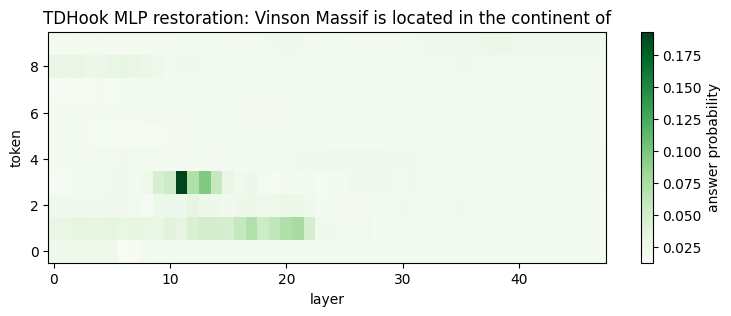

In [4]:
plt.figure(figsize=(9, 3))
plt.imshow(first_heatmap, aspect="auto", origin="lower", cmap="Greens")
plt.xlabel("layer")
plt.ylabel("token")
plt.title("TDHook MLP restoration: " + trace_rows[0]["prompt"])
plt.colorbar(label="answer probability")
plt.show()

## Rank-one editing

For the first ten CounterFact records, the released code derives the ROME update. TDHook applies that update only while the official evaluator measures rewrite efficacy, paraphrase generalization, and neighborhood specificity. The original weight is checked immediately afterward.

In [5]:
hparams = ROMEHyperParams.from_json(official_root / "hparams/ROME/gpt2-xl.json")
edited_cases = []
restored = []

for record in counterfact[:10]:
    request = record["requested_rewrite"]
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        deltas = execute_rome(model, tokenizer, request, hparams)
    weight_name, (left, right) = next(iter(deltas.items()))
    module_path, parameter_name = weight_name.rsplit(".", 1)
    original = nethook.get_parameter(model, weight_name).detach().clone()

    with temporary_rank_one_edit(model, module_path, parameter_name, left, right) as edited_model:
        expected = original + rank_one_update(left, right, original)
        torch.testing.assert_close(nethook.get_parameter(model, weight_name), expected)
        post = compute_rewrite_quality_counterfact(edited_model, tokenizer, record, None, None)

    restored.append(torch.equal(nethook.get_parameter(model, weight_name), original))
    edited_cases.append({"case_id": record["case_id"], "post": post})

counterfact_summary = summarize_counterfact(edited_cases)
counterfact_summary

  0%|          | 0/1000 [00:00<?, ?it/s]

{'number_cases': 10,
 'metrics': {'rewrite_efficacy': 1.0,
  'paraphrase_generalization': 0.9,
  'neighborhood_specificity': 0.6900000000000001}}

## Results

The paper's GPT-2 XL ROME row reports 100.0% efficacy, 96.4% generalization, and 75.4% specificity on the full benchmark. The ten-case run below is a small direct rerun, so its values are shown beside those figures rather than treated as a pass/fail decision.

In [6]:
result = {
    "model": "gpt2-xl",
    "model_revision": MODEL_REVISION,
    "rome_revision": official_revision,
    "device_name": torch.cuda.get_device_name(),
    "trace": {
        "case_ids": [row["case_id"] for row in trace_rows],
        "allclose": all(row["residual"]["matches"] and row["mlp"]["matches"] for row in trace_rows),
        "max_residual_difference": max(row["residual"]["max_abs_difference"] for row in trace_rows),
        "max_mlp_difference": max(row["mlp"]["max_abs_difference"] for row in trace_rows),
        "cases": trace_rows,
    },
    "counterfact": counterfact_summary,
    "paper_table_4": {
        "rewrite_efficacy": 1.0,
        "paraphrase_generalization": 0.964,
        "neighborhood_specificity": 0.754,
    },
    "temporary_edits_restored": all(restored),
}
result_path.write_text(json.dumps(result, indent=2, sort_keys=True) + "\n")
result

{'model': 'gpt2-xl',
 'model_revision': '15ea56dee5df4983c59b2538573817e1667135e2',
 'rome_revision': '0874014cd9837e4365f3e6f3c71400ef11509e04',
 'device_name': 'NVIDIA A100 80GB PCIe',
 'trace': {'case_ids': [0, 1, 2],
  'allclose': True,
  'max_residual_difference': 1.1920928955078125e-07,
  'max_mlp_difference': 2.9802322387695312e-08,
  'cases': [{'case_id': 0,
    'prompt': 'Vinson Massif is located in the continent of',
    'model_answer': 'Antarctica',
    'published_answer': 'Antarctica',
    'clean_probability': 0.09484539926052094,
    'residual': {'atol': 1e-05,
     'rtol': 1e-05,
     'max_abs_difference': 1.1175870895385742e-08,
     'matches': True},
    'mlp': {'atol': 1e-05,
     'rtol': 1e-05,
     'max_abs_difference': 1.4901161193847656e-08,
     'matches': True}},
   {'case_id': 1,
    'prompt': 'Beats Music is owned by',
    'model_answer': 'Apple',
    'published_answer': 'Apple',
    'clean_probability': 0.6837078332901001,
    'residual': {'atol': 1e-05,
     